# **IS4487 Module 7 - Demo code: Data transformation and feature engineering**

This notebook is designed to help you follow along with the **Module 7 Lecture and Reading**, introducing you to Python.

The practice code demos are intended to give you a chance to see working code and can be a source for your lab and assignment work. Each section contains short explanations and annotated code that reflect the steps in the reading.


### Topics for this demo:

* some cleaning
* Scaling- Log, Normalization and Standardization
* Binning
* Encoding
* Feature engineering - feature creation
* some EDA


<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Demos/demo_07_data_transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



## Context: Retail Chain
A national retail chain wants to improve its monthly sales forecasting for 120 stores across multiple states. The dataset includes historical sales data, store locations, product categories, and customer demographics. However, the raw data is inconsistent, incomplete, and difficult to model in its current form.


## Business Task
The business wants more accurate sales forecasts to improve inventory planning and reduce overstock or stockouts. Forecasts need to account for seasonal patterns and customer behavior.


## **Step 1: Import Necessary Python Libraries**

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



## **Step 2: Load Data**

In [76]:
df = pd.read_csv('https://raw.githubusercontent.com/vandanara/UofUtah_IS4487/refs/heads/main/DataSets/superstore_retail_orders.csv')

df.sample(n=5)

,order_id,order_date,order_year_month,customer_name,city,state_province,email,order_type,quantity,product_name,product_line,product_price,product_status
18715,65868,2024-03-09,2024-03,Edward Lee,Phillipshaven,Kansas,edward_lee@email.com,Retail,1.0,"Short-Sleeve Classic Jersey, XL",Clothing,53.99,Active
26003,61930,2024-01-12,2024-01,Arianna Washington,Lanceport,Wisconsin,arianna_washington@email.com,Retail,2.0,E-COSMOS 5V 1.2W Portable Flexible USB LED Light,Accessories,2.29,Active
54821,61078,2023-12-30,2023-12,Shannon Liu,Holmesside,Utah,shannon_liu@email.com,Retail,1.0,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...",Electronics,914.62,Active
30809,70729,2024-05-16,2024-05,Tiffany Cai,Walkershire,Kentucky,tiffany_cai@email.com,Online,2.0,pTron Solero MB301 3A Micro USB Data & Chargin...,Accessories,9.99,Not Active
36569,52789,2023-08-19,2023-08,Gina Martin,Davidfort,Nevada,gina_martin@email.com,Online,2.0,"Half-Finger Gloves, L",Clothing,235481.00,Not Active



## **Step 3: Inspect data**

In [77]:
df.shape

(56043, 13)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56043 entries, 0 to 56042
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          56043 non-null  int64  
 1   order_date        56011 non-null  object 
 2   order_year_month  56011 non-null  object 
 3   customer_name     56043 non-null  object 
 4   city              55569 non-null  object 
 5   state_province    55569 non-null  object 
 6   email             56043 non-null  object 
 7   order_type        56043 non-null  object 
 8   quantity          56004 non-null  float64
 9   product_name      56043 non-null  object 
 10  product_line      56043 non-null  object 
 11  product_price     56043 non-null  float64
 12  product_status    56043 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 5.6+ MB


In [79]:
df.describe()

,order_id,quantity,product_price
count,56043.000000,56004.000000,56043.000000
mean,61668.410578,3.348582,6198.309433
std,7508.142486,422.654112,35784.965255
min,45079.000000,1.000000,2.290000
25%,55644.500000,1.000000,7.950000
50%,61870.000000,1.000000,475.600000
75%,68097.000000,2.000000,914.620000
max,74147.000000,100000.000000,235481.000000


It's very clear that we will be working with many categorical variables, we must think of what data transformations are appropriate

## **Step 4: Clean the data**


### **Step 4A: Missing values**

little caveat here, unlike last week where we decided to save rows and fill missing values by imputation. We will simply drop missing values because our dataset is so large.




In [80]:
print("Null values by column: \n")
print(df.isnull().sum())

Null values by column: 

order_id              0
order_date           32
order_year_month     32
customer_name         0
city                474
state_province      474
email                 0
order_type            0
quantity             39
product_name          0
product_line          0
product_price         0
product_status        0
dtype: int64


In [81]:
df = df.dropna()

#double check null values were dropped
print(f"Check for nulls \n", df.isnull().sum())

Check for nulls 
 order_id            0
order_date          0
order_year_month    0
customer_name       0
city                0
state_province      0
email               0
order_type          0
quantity            0
product_name        0
product_line        0
product_price       0
product_status      0
dtype: int64



### **Step 4B: Handle duplicates**

lets look for exact duplicates

In [82]:
print("Count of Duplicate Rows:", df.duplicated().sum())

Count of Duplicate Rows: 0


Get rid of duplicates if there are any

In [83]:
df = df.drop_duplicates()
print("Count of Duplicate Rows:", df.duplicated().sum())

Count of Duplicate Rows: 0



### **Step 4C: Convert datatypes**

*We will not be converting `product_name` and `city`  into categorical variables:


Convert `order_date` and `order_year_month` into datetime datatype

In [84]:
#convert order_date into datetime datatype
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

#convert and format order_year_month into datetime datatype - notice that you can specify a format
df['order_year_month'] = pd.to_datetime(df['order_year_month'], format='%Y-%m', errors='coerce')



Standardize the `state_province` column

In [85]:
# First, check what unique values you have
print(df['state_province'].unique())

#We need clean the abbreviations into the state names to standardize things. Use a dictionary
abbreve_name = { 'CA': "California", 'TX': 'Texas', 'NY': 'New York', 'NC': 'North Carolina', 'MA': 'Massachusetts', 'AZ': 'Arizona', 'MI':'Michigan'}

#replace abbreviations with names
df['state_province'] = df['state_province'].replace(abbreve_name)


['New Hampshire' 'West Virginia' 'South Dakota' 'Wisconsin' 'Mississippi'
 'Ohio' 'Alabama' 'Virginia' 'New York' 'Maryland' 'Pennsylvania'
 'Georgia' 'Texas' 'Michigan' 'Kentucky' 'Missouri' 'Massachusetts'
 'Illinois' 'Alaska' 'Nebraska' 'Montana' 'Oregon' 'South Carolina'
 'Louisiana' 'Indiana' 'Nevada' 'Delaware' 'Florida' 'Rhode Island'
 'New Mexico' 'Arkansas' 'Utah' 'Tennessee' 'Oklahoma' 'Arizona'
 'California' 'Vermont' 'Connecticut' 'Idaho' 'Colorado' 'Kansas'
 'Minnesota' 'New Jersey' 'TX' 'Iowa' 'Wyoming' 'Washington' 'Hawaii'
 'North Carolina' 'North Dakota' 'Maine' 'NY' 'Canada' 'MA' 'CA' 'Mexico'
 'NC' 'AZ' 'MI']



We have some rows where `state_province` are Canada and Mexico. Lets see how many of our rows are Canadian/Mexican orders

In [86]:
# Show all rows where state_province is exactly 'Mexico'
mexico_rows = df[df['state_province'] == 'Mexico']
print("Number of rows with 'Mexico':", len(mexico_rows))

canada_rows = df[df['state_province'] == 'Canada']
print("Number of rows with 'Canada':", len(canada_rows))

Number of rows with 'Mexico': 20
Number of rows with 'Canada': 18



38 rows isn't significant for this dataset we are going to drop them and then we can convert the `state_province` column into a categorical variable.

Lets check one last time to ensure eveything has been standardized

In [87]:
#remove rows where state_province is Canada or Mexico
df = df[df['state_province'] != 'Canada']
df = df[df['state_province'] != 'Mexico']

df['state_province'] = df['state_province'].astype('category')

#print(len(df['state_province'].unique()))
df['state_province'].unique()

['New Hampshire', 'West Virginia', 'South Dakota', 'Wisconsin', 'Mississippi', ..., 'Washington', 'Hawaii', 'North Carolina', 'North Dakota', 'Maine']
Length: 50
Categories (50, object): ['Alabama', 'Alaska', 'Arizona', 'Arkansas', ..., 'Washington',
                          'West Virginia', 'Wisconsin', 'Wyoming']


Convert `order_type` column into a categorical datatype

In [88]:
#look for any obvious errors
print(df['order_type'].unique())

#convert columns
df['order_type'] = df['order_type'].astype('category')

['Retail' 'Online']



convert `product_line` into a categorical datatype


In [89]:
#look for any obvious errors
print(df['product_line'].unique())

#fixing a quick formatting issue
df['product_line'] = df['product_line'].replace('OfficeProducts', 'Office Products')

#convert into categorical
df['product_line'] = df['product_line'].astype('category')

['Mobile' 'Bikes' 'Cameras' 'Electronics' 'Accessories' 'Clothing'
 'Projector' 'Laptop' 'OfficeProducts']



Convert `product status` into categorical

In [90]:
#look for errors
print(df['product_status'].unique())

#convert into categorical
df['product_status'] = df['product_status'].astype('category')

['Active' 'Not Active']



convert `quantity` into an integer datatype

In [91]:
df['quantity'] = df['quantity'].astype('int32')



make sure we have converted the varibles to their proper datatypes

In [92]:
#Check to see if everything is converted

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55460 entries, 0 to 56042
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          55460 non-null  int64         
 1   order_date        55405 non-null  datetime64[ns]
 2   order_year_month  55405 non-null  datetime64[ns]
 3   customer_name     55460 non-null  object        
 4   city              55460 non-null  object        
 5   state_province    55460 non-null  category      
 6   email             55460 non-null  object        
 7   order_type        55460 non-null  category      
 8   quantity          55460 non-null  int32         
 9   product_name      55460 non-null  object        
 10  product_line      55460 non-null  category      
 11  product_price     55460 non-null  float64       
 12  product_status    55460 non-null  category      
dtypes: category(4), datetime64[ns](2), float64(1), int32(1), int64(1), object(4)
memo


### **Step 4D: Standardizing the formatting of textual columns**

Make sure `customer_name` are formatted consistently

In [93]:
# Step 1: Convert to lowercase
df['customer_name'] = df['customer_name'].str.lower()

# Step 2: Remove numbers and symbols, keep only letters and spaces
df['customer_name'] = df['customer_name'].str.replace(r'[^a-zA-Z\s]', '', regex=True)

# Step 3: Clean up multiple spaces (replace multiple spaces with single space)
df['customer_name'] = df['customer_name'].str.replace(r'\s+', ' ', regex=True)

# Step 4: Strip again to remove any leading/trailing spaces after cleaning
df['customer_name'] = df['customer_name'].str.strip()




## **Step 5: Deal with outliers in key numeric columns**

### **Step 5A: clean up quantity**
Lets clear out obvious outliers

When using `df.describe()` we had a Max for quantity of 100,000 which is most likely an error. Furthermore we can see from the descriptive statistics that orders =2 are in the 75th percentile.  

Let us print the top 10 orders based on quantity and show a few select columns

In [94]:
print("Quantity stats:\n", df['quantity'].describe())

# Show top 10 largest orders
print("\nTop quantities:")
print(df.nlargest(10, 'quantity')[['quantity','product_name', 'customer_name', 'product_price']])


Quantity stats:
 count     55460.000000
mean          3.366462
std         424.721927
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max      100000.000000
Name: quantity, dtype: float64

Top quantities:
       quantity                                       product_name  \
33822    100000                              Water Bottle - 30 oz.   
55308      2000  Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...   
44626       600                                Projector Black, 44   
45857       500                               Gaming Laptop Silver   
33727       200                              Water Bottle - 30 oz.   
45530       100                                      Gaming Laptop   
45752        20                                Gaming Laptop Matte   
2             5  Apple iPhone XR (Yellow, 256 GB) (Includes Ear...   
1             4  Apple iPhone XR (Yellow, 256 GB) (Includes Ear...   
0             3  Apple iPhone XR (Yellow, 256 GB) (

Customers buying one hundred thousand water bottles seems unreasonable.

Buying 2000 phones seems unreasonable

Buying 600 projectors seems unreasonable

etc.

We will identify outliers from quantity using IQR and remove them.

In [95]:
Q1 = df['quantity'].quantile(0.25)
Q3 = df['quantity'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['quantity'] >= Q1 - 1.5*IQR) & (df['quantity'] <= Q3 + 1.5*IQR)]


In [96]:
df.describe()

,order_id,order_date,order_year_month,quantity,product_price
count,55451.000000,55396,55396,55451.000000,55451.000000
mean,61674.590161,2023-11-10 19:42:40.733626624,2023-10-27 04:32:08.283630592,1.501776,6224.351959
min,45079.000000,1922-06-28 00:00:00,1922-06-01 00:00:00,1.000000,2.290000
25%,55659.500000,2023-10-06 00:00:00,2023-10-01 00:00:00,1.000000,7.950000
50%,61886.000000,2024-01-11 00:00:00,2024-01-01 00:00:00,1.000000,475.600000
75%,68085.500000,2024-04-11 00:00:00,2024-04-01 00:00:00,2.000000,914.620000
max,74147.000000,2029-08-02 00:00:00,2029-08-01 00:00:00,3.000000,235481.000000
std,7500.164238,NaN,NaN,0.612326,35865.167552



### **Step 5B: clean up product_price**
Now lets fix the product_price column using the same methods

In [97]:
print("price stats:\n", df['product_price'].describe())

# Show top 5 largest orders
print("\nTop quantities:")
print(df.nlargest(5, 'product_price')[['product_name', 'product_price']])

price stats:
 count     55451.000000
mean       6224.351959
std       35865.167552
min           2.290000
25%           7.950000
50%         475.600000
75%         914.620000
max      235481.000000
Name: product_price, dtype: float64

Top quantities:
                product_name  product_price
36546  Half-Finger Gloves, L       235481.0
36547  Half-Finger Gloves, L       235481.0
36548  Half-Finger Gloves, L       235481.0
36549  Half-Finger Gloves, L       235481.0
36550  Half-Finger Gloves, L       235481.0


Half finger gloves for 235,481 is clearly an error, from our previous analysis of quantity the most expensive item that was realistic was the gaming laptop for about $3,578.27. We will remove values where price >=5,000

In [98]:
df = df[df['product_price'] <= 5000]


In [99]:
df.describe()

,order_id,order_date,order_year_month,quantity,product_price
count,54127.000000,54072,54072,54127.000000,54127.000000
mean,61643.344172,2023-11-10 08:42:55.765645568,2023-10-26 17:36:08.308921344,1.489977,616.507408
min,45079.000000,1922-06-28 00:00:00,1922-06-01 00:00:00,1.000000,2.290000
25%,55624.000000,2023-10-06 00:00:00,2023-10-01 00:00:00,1.000000,7.950000
50%,61857.000000,2024-01-10 00:00:00,2024-01-01 00:00:00,1.000000,475.600000
75%,68061.500000,2024-04-11 00:00:00,2024-04-01 00:00:00,2.000000,914.620000
max,74147.000000,2029-08-02 00:00:00,2029-08-01 00:00:00,3.000000,3578.270000
std,7516.596609,NaN,NaN,0.609819,816.913765


### **Step 5C: clean up order_date**

Using `df.describe()` we saw a minimum year of 1922 and a maximum year of 2029. Lets clean out erroneous dates


In [100]:
# Define valid range (adjust as needed for your dataset)
start_date = "2020-01-01"
end_date   = "2025-12-31"

# Filter rows within the valid range
df = df[(df['order_date'] >= start_date) & (df['order_date'] <= end_date)]


In [101]:
df.describe()


,order_id,order_date,order_year_month,quantity,product_price
count,53926.000000,53926,53926,53926.000000,53926.000000
mean,61617.312206,2023-12-16 01:47:14.417534976,2023-12-01 11:00:11.081852928,1.489764,616.902464
min,45079.000000,2022-01-01 00:00:00,2022-01-01 00:00:00,1.000000,2.290000
25%,55626.000000,2023-10-06 00:00:00,2023-10-01 00:00:00,1.000000,7.950000
50%,61841.500000,2024-01-10 00:00:00,2024-01-01 00:00:00,1.000000,475.600000
75%,68018.750000,2024-04-10 00:00:00,2024-04-01 00:00:00,2.000000,914.620000
max,74146.000000,2024-06-30 00:00:00,2024-06-01 00:00:00,3.000000,3578.270000
std,7498.972670,NaN,NaN,0.609671,817.330327


## **Step 6: Transformation - Rescaling data**

Price is often an important feature or input variable used to predict outcomes.

Price, as seen in the chart below often has two issues.
 - it is often skewed to the right (some products have very high price). THis is very non-normal.
 - its scale is very different than many of the other variables (high range). Useful to have variables (features)  be in similar scales/ranges

 **Log transform price**
 - observe how the range of price has reduced in log form
 - also log scaling attempts to make the shape more normal (doesnt always succedd though)

In [102]:
df["log_price"] = np.log(df['product_price'])


**z-score standardization** and **minmax normalization** of price

two other technqiues existv to reeduce the scale of large scale variables - bot these do not affect or change the underlying shape of the variable.

In [103]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
df['zscore_price'] = scaler.fit_transform(df[['product_price']])

scaler = MinMaxScaler()
df['norm_price'] = scaler.fit_transform(df[['product_price']])

df[['product_price', 'log_price', 'zscore_price', 'norm_price']].describe()


,product_price,log_price,zscore_price,norm_price
count,53926.000000,53926.000000,5.392600e+04,53926.000000
mean,616.902464,4.598592,-1.897381e-17,0.171872
std,817.330327,2.489544,1.000009e+00,0.228561
min,2.290000,0.828552,-7.519826e-01,0.000000
25%,7.950000,2.073172,-7.450575e-01,0.001583
50%,475.600000,6.164577,-1.728845e-01,0.132358
75%,914.620000,6.818509,3.642595e-01,0.255127
max,3578.270000,8.182635,3.623254e+00,1.000000


Let us plot all four price variables - the original plus the three transformations to see what they look like.

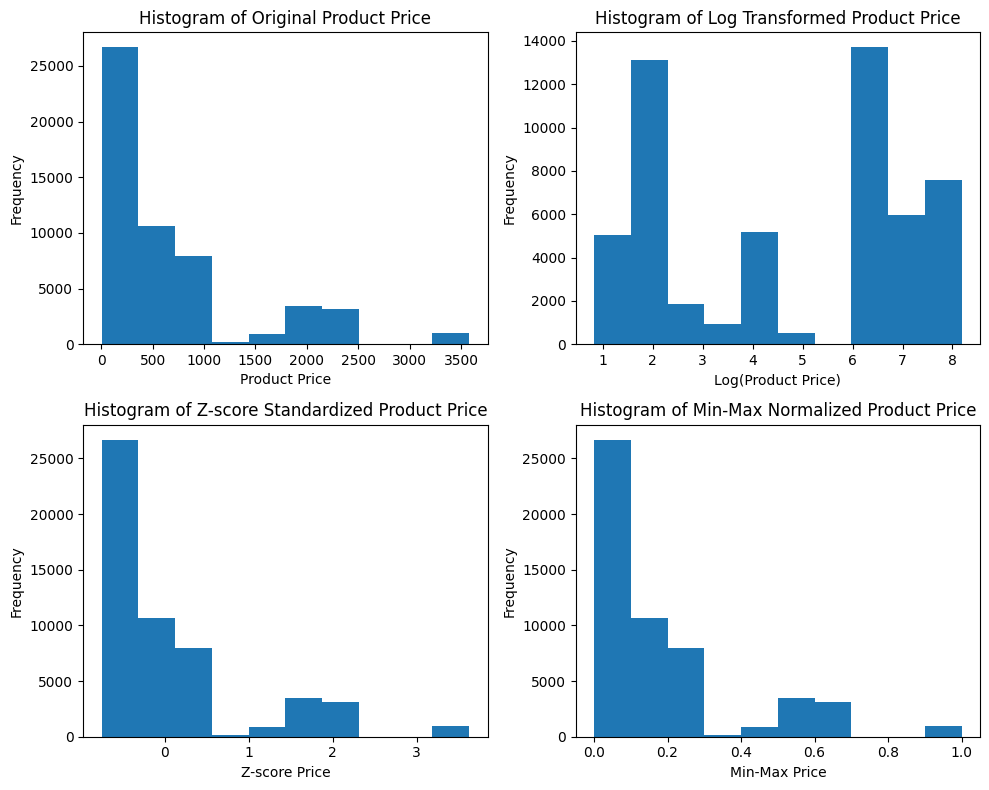

In [104]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))


df['product_price'].plot(kind="hist", ax=axes[0, 0])
axes[0, 0].set_title("Histogram of Original Product Price")
axes[0, 0].set_xlabel("Product Price")
axes[0, 0].set_ylabel("Frequency")

df['log_price'].plot(kind="hist", ax=axes[0, 1])
axes[0, 1].set_title("Histogram of Log Transformed Product Price")
axes[0, 1].set_xlabel("Log(Product Price)")
axes[0, 1].set_ylabel("Frequency")

df['zscore_price'].plot(kind="hist", ax=axes[1, 0])
axes[1, 0].set_title("Histogram of Z-score Standardized Product Price")
axes[1, 0].set_xlabel("Z-score Price")
axes[1, 0].set_ylabel("Frequency")

df['norm_price'].plot(kind="hist", ax=axes[1, 1])
axes[1, 1].set_title("Histogram of Min-Max Normalized Product Price")
axes[1, 1].set_xlabel("Min-Max Price")
axes[1, 1].set_ylabel("Frequency")


plt.tight_layout()
plt.show()

Based on the histograms plotted in the previous step, the log transformation appears to make the product_price distribution the most normal-like. The original product_price is heavily skewed to the right. Both z-score and min-max normalization preserve the shape of the original distribution, only changing the scale. The log transformation, however, compresses the larger values and stretches the smaller values, resulting in a distribution that is closer to a normal distribution (more bell-shaped).

CAVEAT: Normality of features or target is NOT strictly required for ML, but when data are approximately normal  and similar in scale, it can make the algorithms more stable and efficient in their computations, speeding up results. So its a good thing to have.

In [105]:
df.drop(['norm_price', 'zscore_price'], axis = 1, inplace = True)

## **Step 7: Feature Engineering - feature creation**

In [106]:
df.head()

,order_id,order_date,order_year_month,customer_name,city,state_province,email,order_type,quantity,product_name,product_line,product_price,product_status,log_price
0,51188,2023-07-01,2023-07-01,audrey blanco,North Cherylmouth,New Hampshire,audrey_blanco@email.com,Retail,3,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,6.476957
3,51241,2023-07-04,2023-07-01,alexa bell,Lake Tracytown,Wisconsin,alexa_bell@email.com,Online,1,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,6.476957
4,51297,2023-07-08,2023-07-01,casey diaz,Byrdchester,Mississippi,casey_diaz@email.com,Online,1,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,6.476957
5,51319,2023-07-09,2023-07-01,troy rodriguez,South Brendamouth,Ohio,troy_rodriguez@email.com,Online,1,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,6.476957
6,51357,2023-07-11,2023-07-01,natalie phillips,Rachelburgh,Alabama,natalie_phillips@email.com,Online,1,"Apple iPhone XR (Yellow, 256 GB) (Includes Ear...",Mobile,649.99,Active,6.476957



### **Step 7A: Create season column**




In [107]:
#function to determine what season an order is in
def get_season(date):
    month = date.month
    if month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Fall"
    elif month in [12, 1, 2]:
        return "Winter"
    else:
        return "Spring"

# Convert 'order_year_month' to datetime objects before applying the function
df['order_year_month'] = pd.to_datetime(df['order_year_month'])

#use df['col'].apply() to apply a function to every value in the column
df['season'] = df['order_year_month'].apply(get_season)

#convert the new season column into a categorical datatype
df['season'] = df['season'].astype('category')


### **Step 7B: Create revenue column**

Our ultimate target is revenue (or sales), per month. Our current data is transactional, so we know that sales will need to be aggregated from this current data. BUt the current data only has a price and qty column for each order-product purchased by a customer - so we will need to calculate a new column called revenue (or sales).

We know revenue depends on price and quantity. Note we use price not log_price to calculate actual sales.



In [108]:
df["revenue"] = df["quantity"] * df["product_price"]


### **Step 7C: Create high value order column**

In [109]:
# Use median revenue as the cutoff
cutoff = df['revenue'].median()

# Create Yes/No column for high value orders
df['high_value_order'] = np.where(df['revenue'] > cutoff, "Yes", "No")

#convert high value order into categorical datatype
df['high_value_order'] = df['high_value_order'].astype('category')

In [110]:
df.sample(n = 5)

,order_id,order_date,order_year_month,customer_name,city,state_province,email,order_type,quantity,product_name,product_line,product_price,product_status,log_price,season,revenue,high_value_order
16117,55006,2023-09-26,2023-09-01,veronica madan,Johnmouth,Georgia,veronica_madan@email.com,Retail,2,GIZGA essentials Universal Silicone Keyboard P...,Accessories,4.99,Active,1.607436,Fall,9.98,No
47703,61624,2024-01-07,2024-01-01,hunter scott,Lake Kendra,Illinois,hunter_scott@email.com,Retail,1,"Long-Sleeve Logo Jersey, S",Clothing,48.07,Active,3.872658,Winter,48.07,No
28841,69307,2024-04-29,2024-04-01,vincent hu,North Jesse,Connecticut,vincent_hu@email.com,Online,2,Road Bottle Cage,Accessories,8.99,Active,2.196113,Spring,17.98,No
20052,53212,2023-08-27,2023-08-01,samuel campbell,North Mitchellberg,Nebraska,samuel_campbell@email.com,Retail,1,Hydration Pack - 70 oz.,Accessories,54.99,Active,4.007151,Summer,54.99,No
14822,65069,2024-02-28,2024-02-01,preston chapman,New Seth,New Hampshire,preston_chapman@email.com,Online,2,Inventis 5V 1.2W Portable Flexible USB LED Lig...,Accessories,3.99,Active,1.383791,Winter,7.98,No


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53926 entries, 0 to 56042
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          53926 non-null  int64         
 1   order_date        53926 non-null  datetime64[ns]
 2   order_year_month  53926 non-null  datetime64[ns]
 3   customer_name     53926 non-null  object        
 4   city              53926 non-null  object        
 5   state_province    53926 non-null  category      
 6   email             53926 non-null  object        
 7   order_type        53926 non-null  category      
 8   quantity          53926 non-null  int32         
 9   product_name      53926 non-null  object        
 10  product_line      53926 non-null  category      
 11  product_price     53926 non-null  float64       
 12  product_status    53926 non-null  category      
 13  log_price         53926 non-null  float64       
 14  season            53926 non


## **Step 8: More transformation - Encode categories of interest**

For this example we will one hot encode season and binary encode order type to use for comparing online vs retail sales

You could do much more encoding but for our purposes we will keep things simple






### **Step 8A: One-Hot-encode season**

In [112]:
# Encode season into dummy variables. Creates: season_Fall, season_Winter, season_Spring, season_Summer
df['season_all'] = df['season']  # keep a copy column of original values
df = pd.get_dummies(df, columns=['season'], drop_first=False)

# show/filter for only the columns that contain season
print(df.filter(like='season').sample(n=5))


      season_all  season_Fall  season_Spring  season_Summer  season_Winter
53267     Spring        False           True          False          False
31800       Fall         True          False          False          False
36271     Winter        False          False          False           True
29223     Summer        False          False           True          False
138       Winter        False          False          False           True



### **Step 8B: encode order_type**

In [113]:
# This column was already encoded in a previous step.
# df['order_type'] = df['order_type'].astype(str)
df['order_type_all'] = df['order_type']

df = pd.get_dummies(df, columns=['order_type'], drop_first=False)
print(df.filter(like='order_type').sample(n=5))

      order_type_all  order_type_Online  order_type_Retail
42122         Retail              False               True
25590         Retail              False               True
18683         Retail              False               True
2835          Retail              False               True
31654         Online               True              False


## **Step 9: Binning**

We will bin date into quarters - so we can compare revenue across year and quarters

In [114]:
# Extract year if not already separate
df['year'] = df['order_date'].dt.year

# Binning by day of the year (e.g., into 4 bins)
df['qtr_bin'] = pd.cut(df['order_date'].dt.dayofyear, bins=4, labels=['q1', 'q2', 'q3', 'q4'])

print(df[['order_date','year', 'qtr_bin']].sample(10))

      order_date  year qtr_bin
9804  2024-03-18  2024      q1
327   2024-05-23  2024      q2
44946 2022-08-09  2022      q3
38508 2023-09-06  2023      q3
18095 2024-05-16  2024      q2
41162 2022-11-21  2022      q4
55820 2024-05-29  2024      q2
19423 2024-01-21  2024      q1
27893 2023-10-21  2023      q4
23219 2023-12-13  2023      q4


In [115]:
# ordinal encode qtr_bin so they can be used
quarter_map = {'q1': 1, 'q2': 2, 'q3': 3, 'q4': 4}
df['qtr_bin_num'] = df['qtr_bin'].map(quarter_map)

# change its datatype to int
df['qtr_bin_num'] = df['qtr_bin_num'].astype(int)

# view some values
print(df[['order_date', 'year', 'qtr_bin', 'qtr_bin_num']].sample(10))

      order_date  year qtr_bin  qtr_bin_num
22634 2024-05-24  2024      q2            2
32051 2023-10-24  2023      q4            4
21674 2023-12-14  2023      q4            4
34390 2024-05-09  2024      q2            2
50227 2023-09-06  2023      q3            3
16388 2023-10-30  2023      q4            4
8005  2023-07-25  2023      q3            3
29218 2023-07-08  2023      q3            3
16378 2023-10-28  2023      q4            4
6804  2024-02-08  2024      q1            1


## **Step 10: Graph relationships**

Bar chart of total revenue across order_type (retail vs online)

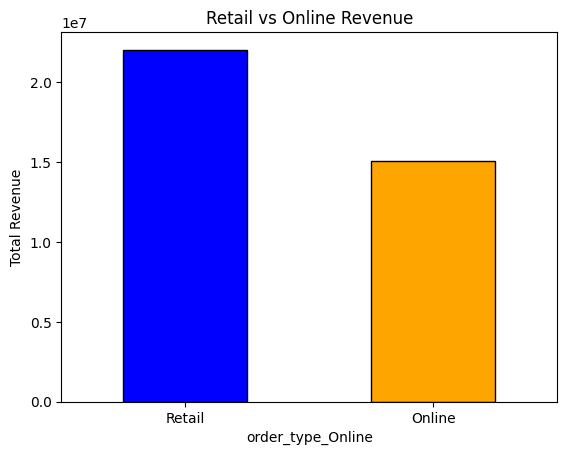

In [116]:
df.groupby('order_type_Online')['revenue'].sum().plot(
    kind='bar', color=['blue', 'orange'], edgecolor='black'
)
plt.xticks([0,1], ['Retail', 'Online'], rotation=0)
plt.ylabel("Total Revenue")
plt.title("Retail vs Online Revenue")
plt.show()


Bar chart of total revenue by year and dummy season columns

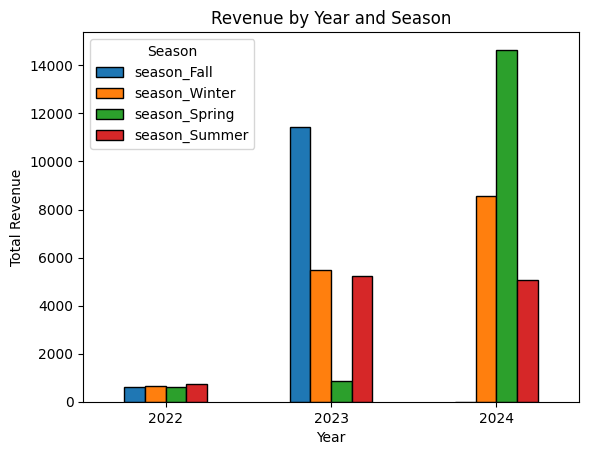

In [117]:

season_rev = df.groupby('year')[['season_Fall','season_Winter','season_Spring','season_Summer']].sum()

# Plot grouped bar chart
season_rev.plot(kind='bar', edgecolor='black')

plt.title("Revenue by Year and Season")
plt.ylabel("Total Revenue")
plt.xlabel("Year")
plt.xticks(rotation=0)
plt.legend(title="Season")
plt.show()


Bar chart of total revenue by year

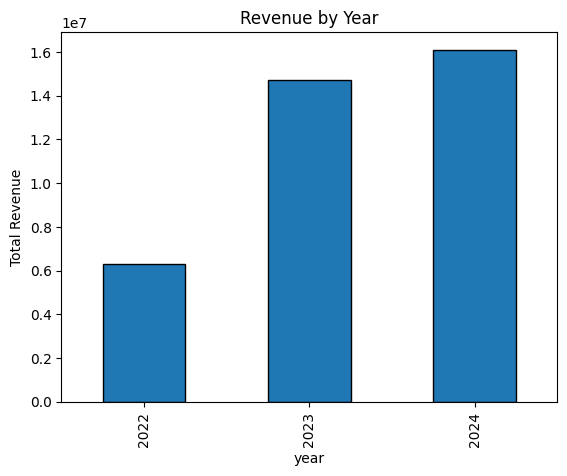

In [118]:
df.groupby('year')['revenue'].sum().plot(kind='bar', edgecolor='black')
plt.ylabel("Total Revenue")
plt.title("Revenue by Year")
plt.show()


Line chart of total revenue across quatrers

/tmp/ipython-input-2665830899.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_year_qtr = df.groupby(['year', 'qtr_bin'])['revenue'].sum()


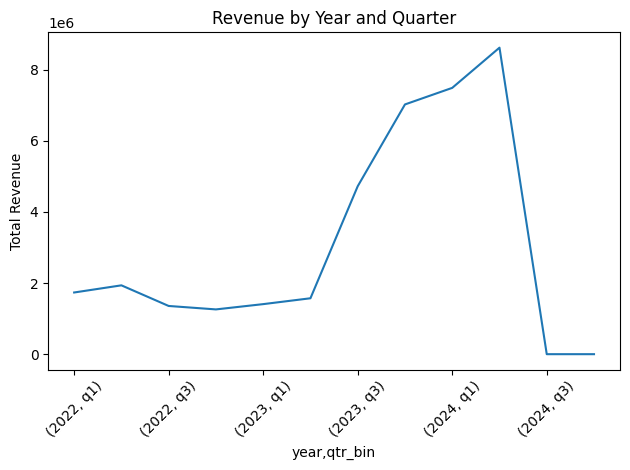

In [119]:
# Group by year and quarter and sum the revenue
revenue_by_year_qtr = df.groupby(['year', 'qtr_bin'])['revenue'].sum()

# Plot the line chart
revenue_by_year_qtr.plot(kind='line')
plt.ylabel("Total Revenue")
plt.title("Revenue by Year and Quarter")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Let us check out correlations between our target - revenue - and other features.

In [120]:
# check correlations
df.corr(numeric_only = True)['revenue']

,revenue
order_id,-0.267183
quantity,-0.339686
product_price,0.962086
log_price,0.822227
revenue,1.000000
season_Fall,-0.061155
season_Spring,0.033669
season_Summer,0.021689
season_Winter,0.002872
order_type_Online,-0.105592
